# Numpy (5 points)

In [87]:
import numpy as np

## Task 1 (1 point)



Create function `find_index_closest` that find the index of the closest elements with the same index. If there are several indices, return the first one.


In [89]:
def find_index_closest(array1, array2):
    arr = np.abs(array2-array1)
    closest = np.min(arr)
    for i in range(len(arr)):
        if arr[i] == closest:
            index = i
            return index

In [91]:
#Cell for testing
#Do not change this cell
np.random.seed(0)


a1 = np.array([1, 2, 3])
b1 = np.array([100, 55, 78])
'''
For index 0 - the distance is 99
For index 1 - the distance is 53
For index 2 - the distance is 75

So, the function should return 1
'''
assert find_index_closest(a1, b1) == 1



a1 = np.array([1, 2, 3])
b1 = np.array([1, 2, 78])
assert find_index_closest(a1, b1) == 0

assert find_index_closest(np.random.rand(5), np.random.rand(5)) == 4
assert find_index_closest(np.random.rand(5), np.random.rand(5)) == 3
assert find_index_closest(np.random.rand(5), np.random.rand(5)) == 3
assert find_index_closest(np.random.rand(1000), np.random.rand(1000)) == 205

## Task 2 (1 point)




Create function `prod_no_zeros` that computes the product of non-zero elements.


In [93]:
def prod_no_zeros(matrix):
    prod = np.prod(matrix[matrix != 0])
    return prod

In [95]:
#Cell for testing
#Do not change this cell
np.random.seed(0)
a2 = np.array([[1, 0, 3, 0, 5],
               [0, 0, 2, 4, 0]])
'''
The product is - 1 * 3 * 5 * 2 * 4 = 120
'''
assert prod_no_zeros(a2) == 120

assert np.allclose(prod_no_zeros(np.ones((4, 5))), 1.0)

r = np.random.rand(3, 4)
r[np.random.randint(3, size=2), np.random.randint(4, size=2)] = 0.0
assert np.allclose(prod_no_zeros(r), 0.004610776903132477)

r = np.random.rand(3, 4)
r[np.random.randint(3, size=10), np.random.randint(4, size=10)] = 0.0
assert np.allclose(prod_no_zeros(r), 0.06700531187530212)

r = np.random.rand(3, 4, 5) * 5
r[np.random.randint(3, size=10), np.random.randint(4, size=10), np.random.randint(5, size=10)] = 0.0
assert np.allclose(prod_no_zeros(r), 294641039.92862517)

## Task 3 (1 point)


Create function `sum_antidiagonal_even` that computes the sum of elements on anti-diagonal (secondary diagonall, that goes from top right to bottom left).

In [97]:
def sum_antidiagonal_even(matrix):
    matrix_flipped = np.fliplr(matrix)
    matr_antidiag = np.diag(matrix_flipped)
    sum_antidiag_even = np.sum(matr_antidiag[matr_antidiag % 2 == 0])
    return sum_antidiag_even

In [99]:
#Cell for testing
#Do not change this cell
np.random.seed(0)

a = np.array([[1, 2, 3],
              [3, 4, 5],
              [6, 7, 8]])

'''
Element on anti-diagonal  are 3, 4, 6
The sum of even - 4 + 6 = 10
'''
assert sum_antidiagonal_even(a) == 10

a = np.array([[1, 2, 3],
              [3, -5, 5],
              [5, 7, 8]])
assert sum_antidiagonal_even(a) == 0

a = np.array([[1, 2],
              [3, 5]])
assert sum_antidiagonal_even(a) == 2

assert sum_antidiagonal_even(np.random.randint(-10, 10, (10, 10))) == -36
assert sum_antidiagonal_even(np.random.randint(-10, 10, (10, 10))) == 4
assert sum_antidiagonal_even(np.random.randint(-10, 10, (10, 10))) == -10

## Task 4 (2 points)

A matrix `product_customer` contains the expenses of the customers (columns) on the products (rows).

Create a function `ratio_product` that computes the share of expense the product `i` for every customer.


If the buyer did not spend anything at all, then the share should be 0.



In [101]:
def ratio_product(product_customer, i):
    prod_n, cust_n = product_customer.shape
    spending = np.zeros(cust_n)
    for j in range (cust_n):
        if (product_customer[i,j] != 0):
            spending[j] = product_customer[i, j] / np.sum(product_customer[:,j])
        else:
            spending[j] = 0
    return spending

In [103]:
#Cell for testing
#Do not change this cell
np.random.seed(0)

#2 products, 3 customers
r = np.array([[1, 2, 3],
                             [4, 5, 6]])
'''
The first consumer spend in total 1 + 4 = 5, so the share of the product 0 is 1/4 = 0.2
The second consumer spend in total 2 + 5 = 7, so the share of the product 0 is 2/7 = 0.28571429
The third consumer spend in total 3 + 6 = 9, so the share of the product 0 is 3/9 = 0.33333333
'''
assert np.allclose(ratio_product(r, 0), np.array([0.2, 0.28571429, 0.33333333]))


r = np.random.rand(4, 3)

assert np.allclose(ratio_product(r, 0), np.array([0.28662778, 0.25340278, 0.21988911]))
assert np.allclose(ratio_product(r, 1), np.array([0.2845751 , 0.15010752, 0.23562328]))
assert np.allclose(ratio_product(r, 2), np.array([0.22853784, 0.31596913, 0.35154583]))
assert np.allclose(ratio_product(r, 3), np.array([0.20025927, 0.28052057, 0.19294177]))


r = np.random.rand(3, 4)
r[:,1] = 0.0

assert np.allclose(ratio_product(r, 0), np.array([0.36253197, 0.0, 0.05419819, 0.05014144]))
assert np.allclose(ratio_product(r, 1), np.array([0.01290359, 0.0, 0.59370815, 0.50067725]))
assert np.allclose(ratio_product(r, 2), np.array([[0.62456444, 0.0, 0.35209366, 0.44918132]]))

# Matplotlib (5 points)

In [105]:
import numpy as np
import matplotlib.pyplot as plt

**Task 1** (5 points)

Create the plot as close as possible to the following one:

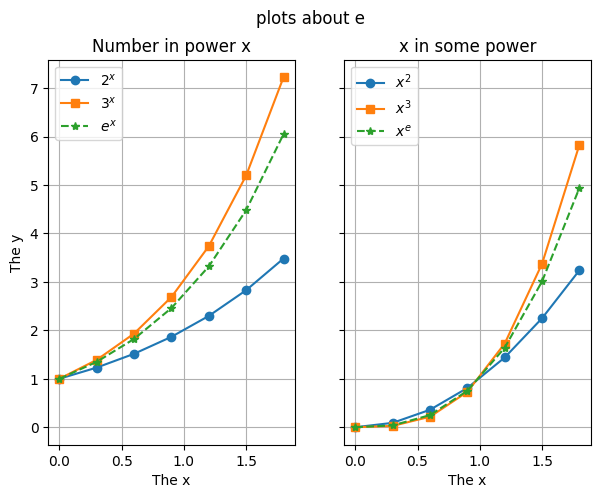

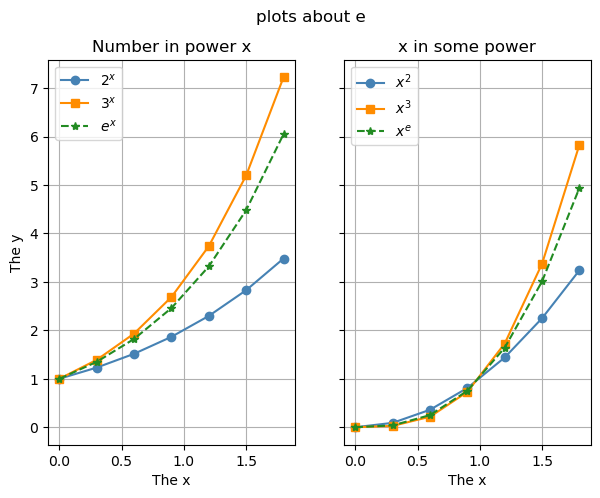

In [107]:
x = np.arange(0, 2, 0.3)
y = pow(2, x)
fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(7,5), sharex=True, sharey = True)
fig.suptitle('plots about e')
ax[0].plot(x, y,
         color='steelblue',
         linestyle='-',
         label=r'$2^x$',
         marker='.',
         mec='steelblue',
         mfc='steelblue',
         ms=12
         )

y = pow(3, x)

ax[0].plot(x, y,
         color='darkorange',
         linestyle='-',
         label=r'$3^x$',
         marker='s',
         mec='darkorange',
         mfc='darkorange',
         ms=6
         )

y = np.exp(x)

ax[0].plot(x, y,
         color='forestgreen',
         linestyle='--',
         label=r'$e^x$',
         marker='*',
         mec='forestgreen',
         mfc='forestgreen',
         ms=6
         )

ax[0].set_title('Number in power x')
ax[0].set_xlabel('The x')
ax[0].set_ylabel('The y')
ax[0].grid()
ax[0].legend()

y = pow(x, 2)

ax[1].plot(x, y,
         color='steelblue',
         linestyle='-',
         label=r'$x^2$',
         marker='.',
         mec='steelblue',
         mfc='steelblue',
         ms=12
         )

y = pow(x, 3)

ax[1].plot(x, y,
         color='darkorange',
         linestyle='-',
         label=r'$x^3$',
         marker='s',
         mec='darkorange',
         mfc='darkorange',
         ms=6
         )

y = pow(x, 2.71828)

ax[1].plot(x, y,
         color='forestgreen',
         linestyle='--',
         label=r'$x^e$',
         marker='*',
         mec='forestgreen',
         mfc='forestgreen',
         ms=6
         )

ax[1].set_title('x in some power')
ax[1].set_xlabel('The x')
ax[1].grid()
ax[1].legend()

plt.show()